<a href="https://colab.research.google.com/github/josenomberto/UTEC-CDIAV3-MCD8015/blob/main/src/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis Exploratorio de Datos (EDA)

## UTEC Postgrado - Maestría en Ciencia de Datos e IA

* Curso: Proyecto Integrador I
* Proyecto 3: Precio Dinámico de Alojamientos CDMX
* Integrantes:
  - Herles Alejandro Pinedo
  - David Jimenez
  - José Carlos Nomberto


## Etapa E2: Comprensión de los Datos
En esta etapa, abordaremos las tareas de recopilar, describir, explorar y verificar la calidad de los datos para sustentar los bloques 6 al 9 de nuestro One-Pager.

### E2.0 Importación de librerias y configuraciones
Importamos las librerias necesarias y configuramos parametros para visualización de gráficos

In [ ]:
import os
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Configuración visual
sns.set_theme(style="whitegrid")
#plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

### E2.1 Recopilación Inicial de Datos
Cargaremos los tres archivos fuente en formato Parquet que componen nuestro dataset

In [ ]:
# Carga de los datasets en formato parquet

DATA_DIR = "data/raw/"
LISTINGS_PATH = os.path.join(DATA_DIR, "airbnb_listings.parquet")
CALENDAR_PATH = os.path.join(DATA_DIR, "airbnb_calendar.parquet")
REVIEWS_PATH = os.path.join(DATA_DIR, "airbnb_reviews.parquet")
OUTPUT_IMG_DIR = "notebooks/figures"

print("====== Iniciando carga optimizada de datos ======")

try:
    print(f"Cargando Anuncios desde: {LISTINGS_PATH}...")
    df_listings = pd.read_parquet('airbnb_listings.parquet')
    print(f"Carga de Anuncios exitosa")
    print(f"Cargando Calendario (escala masiva) desde: {CALENDAR_PATH}...")
    df_calendar = pd.read_parquet('airbnb_calendar.parquet')
    print(f"Carga de Calendario exitosa")
    print(f"Cargando Reseñas desde: {REVIEWS_PATH}...")
    df_reviews = pd.read_parquet('airbnb_reviews.parquet')
    print(f"Carga de Reseñas exitosa")
except Exception as e:
    print(f"Error al cargar los datos: {e}")

Acceso a los datos: Disponible (Bloque 6 del One-Pager)


### E2.2 Descripción de los Datos
Según la cartera de proyectos, esperamos las siguientes dimensiones:
* **Anuncios (Listings):** 31 430 filas y 90 columnas.
* **Calendario:** 11,5 millones de noches.
* **Reseñas:** 1,7 millones de reseñas.

Validaremos que los datos cargados correspondan con estas dimensiones.

In [ ]:
# Verificación de volumen de registros (Bloque 6 del One-Pager)
print("=== Verificación de Dimensiones de los Datasets ===")
print(f"Listings: {df_listings.shape[0]:,} filas, {df_listings.shape[1]} columnas")
print(f"Calendar: {df_calendar.shape[0]:,} filas, {df_calendar.shape[1]} columnas")
print(f"Reviews:  {df_reviews.shape[0]:,} filas, {df_reviews.shape[1]} columnas")


# Vista preliminar de la tabla principal
print("=== Vista preliminar de tabla Listings ===")
display(df_listings.head(3))

# Validación de las dimensiones del data
print("=== Validación de Dimensiones de los Datasets ===")
df_listing_val = df_listings.shape[0]: == 31430 and df_listings.shape[1] == 90
df_calendar_val = df_calendar.shape[0]: == 11500000 and df_calendar.shape[1] == 4
df_reviews_val = df_reviews.shape[0]: == 1700000
print(f"Listings validado: {df_listings_val}")
print(f"Calendar validado: {df_calendar_val}")
print(f"Reviews validado: {df_reviews_val}")

=== Dimensiones de los Datasets ===
Listings: 31,430 filas, 90 columnas
Calendar: 11,471,961 filas, 5 columnas
Reviews:  1,719,730 filas, 6 columnas


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,1698274831948209016,https://www.airbnb.com/rooms/1698274831948209016,20260615212254,2026-06-16,city scrape,Roma Residence | Luxury Suite 305,"Discover Condesa Residence Luxury Suites, excl...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,471105419,...,NaN,NaN,NaN,NaN,NaN,42,42,0,0,NaN
1,1120444645818769896,https://www.airbnb.com/rooms/1120444645818769896,20260615212254,2026-06-17,city scrape,Grande y bonita habitación con cocina y baño,Disconnect from your worries in this spacious ...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,548898239,...,NaN,NaN,NaN,NaN,NaN,1,1,0,0,NaN
2,1414477907775396874,https://www.airbnb.com/rooms/1414477907775396874,20260615212254,2026-06-17,city scrape,Ven a sentirte como en casa.,Relax with the whole family at this peaceful p...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,49281983,...,NaN,NaN,NaN,NaN,NaN,2,0,2,0,NaN


### E2.3 Exploración de los Datos y Hallazgos
Para cumplir con la regla de exploración de la Tarea 2.3 de CRISP-DM, no basta con hacer gráficos de todo. Cada hallazgo debe registrarse con su cifra, su interpretación y la consecuencia que tendrá para la etapa E3 (Preparación de los Datos).

A continuación, validaremos las trampas técnicas anticipadas por la cartera de proyectos.

#### Hallazgo 1: Naturaleza del campo "precio"


In [ ]:
# Observamos el formato de la columna precio en listings
if 'price' in df_listings.columns:
    print("Ejemplos de precios en Listings:")
    display(df_listings['price'].head())

Ejemplos de precios en Listings:


,price
0,"$2,066.00"
1,$628.00
2,$499.00
3,"$2,511.00"
4,"$8,263.24"


In [ ]:
# Observamos el formato de la columna precio en calendar

if 'price' in df_calendar.columns:
    print("\nEjemplos de precios en Calendar:")
    display(df_calendar['price'].head())

**Hallazgo 1: Formato del Precio**
* **Cifra / Interpretación:** Los precios están registrados como cadenas de texto que incluyen símbolos de moneda (ej. "$").
* **Consecuencia (para E3):** En la etapa de preparación (E3), será obligatorio limpiar estos caracteres y convertir la columna a tipo numérico (float) antes de poder modelar la regresión. Esta transformación deberá anotarse en el pipeline reproducible.

**Hallazgo 1: Precio promedio por noche **

In [ ]:
    # Limpieza de variable 'price'
    if df_listings['price'].dtype == 'object':
        print("Detectado: La variable de precio es de tipo texto")
        df_listings['price_cleaned'] = (
            df_listings['price']
            .str.replace('$', '', regex=False)
            .str.replace(',', '', regex=False)
            .astype(float)
        )
    else:
        df_listings['price_cleaned'] = df_listings['price'].astype(float)

    print(f"Precio promedio inicial de CDMX por noche: ${df_listings['price_cleaned'].mean():.2f} MXN")


#### Hallazgo 2: Anuncios fantasmas y distorsiones


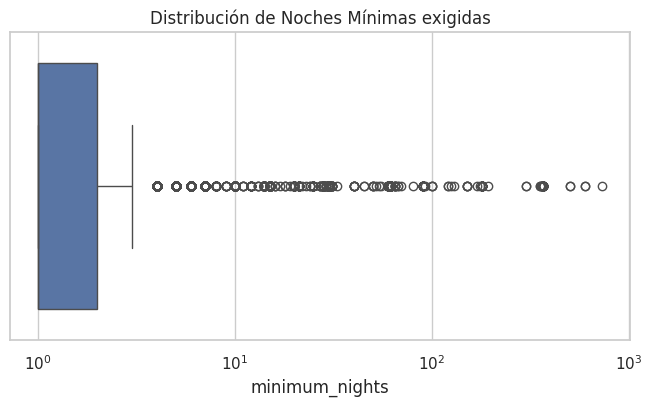

Anuncios que exigen más de 1 año de estadía mínima: 5


In [ ]:
# Exploramos la disponibilidad y las restricciones de noches mínimas

print("\nAnalizando mínimos de noches exigidos por los anfitriones...")

if 'minimum_nights' in df_listings.columns:

    # Descripción estadistica de columnna "minimum_nights"
    nights_stats = df_listings['minimum_nights'].describe(percentiles=[0.5, 0.9, 0.95, 0.99])
    print(nights_stats.to_frame().T)

    # Gráfico de distribución de "minimum_nights"
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df_listings['minimum_nights'])
    plt.title("Distribución de Noches Mínimas exigidas")
    plt.xscale('log') # Escala logarítmica por posibles valores extremos
    plt.show()


    # Identificación de anuncios con estadia mínima > 30 días (outliers)
    extreme_min_nights = df_listings[df_listings['minimum_nights'] > 30].shape
    print(f"Anuncios que exigen estancias mayores a 30 días (outliers de modelo turísticos): {extreme_min_nights} ({extreme_min_nights/len(df_listings)*100:.2f}%)")

    # Identificación de anuncios con estadia mínima > 365 días (fantasmas)
    anuncios_fantasma = df_listings[df_listings['minimum_nights'] > 365]
    print(f"Anuncios que exigen estancias mayores a 365 días (anuncios fantasmas): {len(anuncios_fantasma)}")


**Hallazgo 2: Anuncios fantasma y distorsiones**
* **Cifra / Interpretación:** Existen mínimos de noches que distorsionan la realidad comercial (ej. más de 365 días), lo que apunta a la existencia de "anuncios fantasma" sin intención real de alquiler de corta estancia[cite: 1].
* **Consecuencia (para E3):** Se deberá establecer un umbral analítico justificado para filtrar estos registros, descartando los anuncios que no pertenezcan al objetivo del negocio (cortas estancias)[cite: 3].

#### Hallazgo 3: Multilinguismo en las reseñas


In [ ]:
# Revisamos comentarios en muestra aleatoria de reseñas
if 'comments' in df_reviews.columns:
    print("Muestra aleatoria de reseñas:")
    display(df_reviews['comments'].dropna().sample(5, random_state=42))

Muestra aleatoria de reseñas:


,comments
1045093,Muy cómodo!
1377138,"Muy recomendable, es muy agradable y cercano a..."
219834,"This is an amazing place to stay at, great loc..."
1106195,"Excelente ubicación, me sentí como en casa gra..."
1307266,Gran estancia y gran comunicación por parte de...


**Hallazgo 3: Naturaleza del texto en las reseñas**
* **Cifra / Interpretación:** Las reseñas escritas por los huéspedes se encuentran en varios idiomas[cite: 1].
* **Consecuencia (para E3):** Al usar PLN (Procesamiento de Lenguaje Natural) para extraer el sentimiento y aspectos del anuncio, no podemos asumir que todo el texto está en español o inglés[cite: 1]. Se requerirá un modelo multilingüe o una etapa de detección y filtrado de idioma en el pipeline de datos[cite: 1, 4].

### E2.4 Verificación de Calidad de los Datos (Bloque 8 del One-Pager)
La calidad de los datos se evalúa cuantificando los faltantes, cardinalidad y valores atípicos[cite: 3]. Esta tarea diferencia los datos *inválidos* (que se corrigen de inmediato o se anulan) de los datos *válidos pero incómodos* (que se documentan en el plan de calidad para tratarlos en E3)[cite: 3].

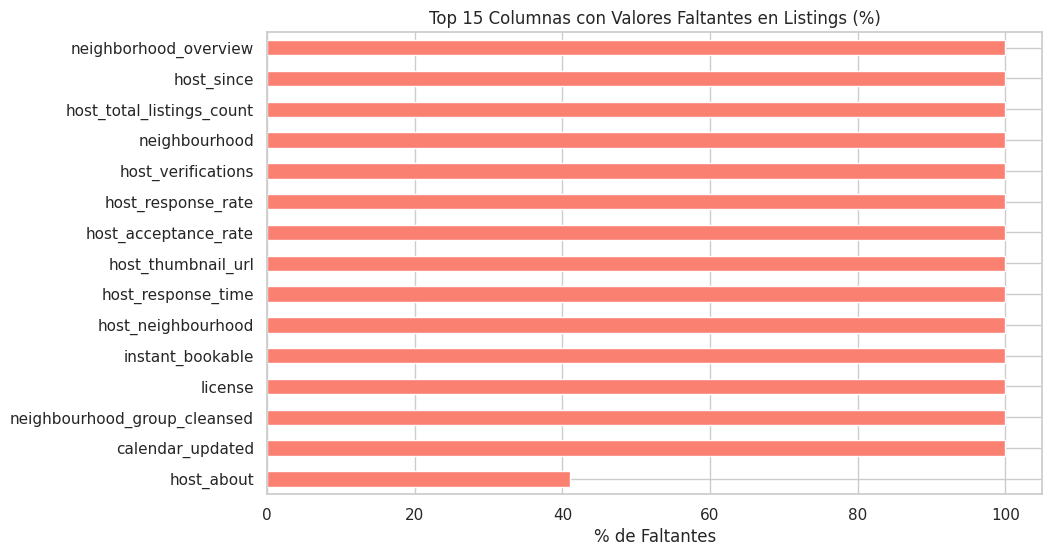

Alta cardinalidad detectada en (Top 5):
 - listing_url: 31430 valores únicos
 - picture_url: 30563 valores únicos
 - name: 29847 valores únicos
 - amenities: 28909 valores únicos
 - description: 25549 valores únicos


In [ ]:
# Cálculo del porcentaje de nulos por columna en Listings (Top 15)
null_percentages = (df_listings.isnull().sum() / len(df_listings)) * 100
top_nulls = null_percentages[null_percentages > 0].sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top_nulls.plot(kind='barh', color='salmon')
plt.title("Top 15 Columnas con Valores Faltantes en Listings (%)")
plt.xlabel("% de Faltantes")
plt.gca().invert_yaxis()
plt.show()

# Resumen de cardinalidad de variables categóricas
cat_cols = df_listings.select_dtypes(include=['object', 'category']).columns
cardinality = {col: df_listings[col].nunique() for col in cat_cols}
print("Alta cardinalidad detectada en (Top 5):")
for k, v in sorted(cardinality.items(), key=lambda item: item[1], reverse=True)[:5]:
    print(f" - {k}: {v} valores únicos")

**Conclusión de la Etapa 2 (Respuesta a la pregunta de cierre):**
* **¿Los datos alcanzan para el objetivo de minería (predecir precio y demanda)?**
Sí, los datos son suficientes[cite: 3]. Sin embargo, se requerirán fuertes mitigaciones en la etapa E3 (Preparación) debido a las fugas clínicas (datos que solo se conocen después de la reserva), limpieza de caracteres en la variable objetivo (`price`), y agrupaciones geográficas para evitar cardinalidad inmanejable[cite: 1, 3].